In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
# load dataset 

energy_df = pd.read_csv(r"E:\OptiCore_AI\data\raw\energy_dataset.csv")
weather_df = pd.read_csv(r"E:\OptiCore_AI\data\raw\weather_features.csv")

In [3]:
# energy dataset 

energy_df['time'] = pd.to_datetime(energy_df['time'], utc=True)

energy_df['hour'] = energy_df['time'].dt.hour
energy_df['day'] = energy_df['time'].dt.day
energy_df['month'] = energy_df['time'].dt.month
energy_df['weekday'] = energy_df['time'].dt.weekday

energy_df['is_weekend'] = energy_df['weekday'].apply(lambda x: 1 if x >= 5 else 0)

In [4]:
# weather dataset 

weather_df['dt_iso'] = pd.to_datetime(weather_df['dt_iso'], utc=True)

weather_df['hour'] = weather_df['dt_iso'].dt.hour
weather_df['day'] = weather_df['dt_iso'].dt.day
weather_df['month'] = weather_df['dt_iso'].dt.month
weather_df['weekday'] = weather_df['dt_iso'].dt.weekday

weather_df['is_weekend'] = weather_df['weekday'].apply(lambda x: 1 if x >= 5 else 0)

In [5]:
# Lag features
energy_df['load_lag_1'] = energy_df['total load actual'].shift(1)
energy_df['load_lag_24'] = energy_df['total load actual'].shift(24)
energy_df['load_lag_168'] = energy_df['total load actual'].shift(168)


In [6]:
energy_df = energy_df.dropna(subset=[
    'load_lag_1',
    'load_lag_24',
    'load_lag_168'
])

# Fill weather missing values
weather_df = weather_df.fillna(weather_df.mean(numeric_only=True))

In [7]:
# save process dataset(use data/processed folder )
energy_df.to_csv(r"E:\OptiCore_AI\data\processed\energy_final.csv", index=False)
weather_df.to_csv(r"E:\OptiCore_AI\data\processed\weather_final.csv", index=False)

Numeric Feature Shape: (35064, 33)


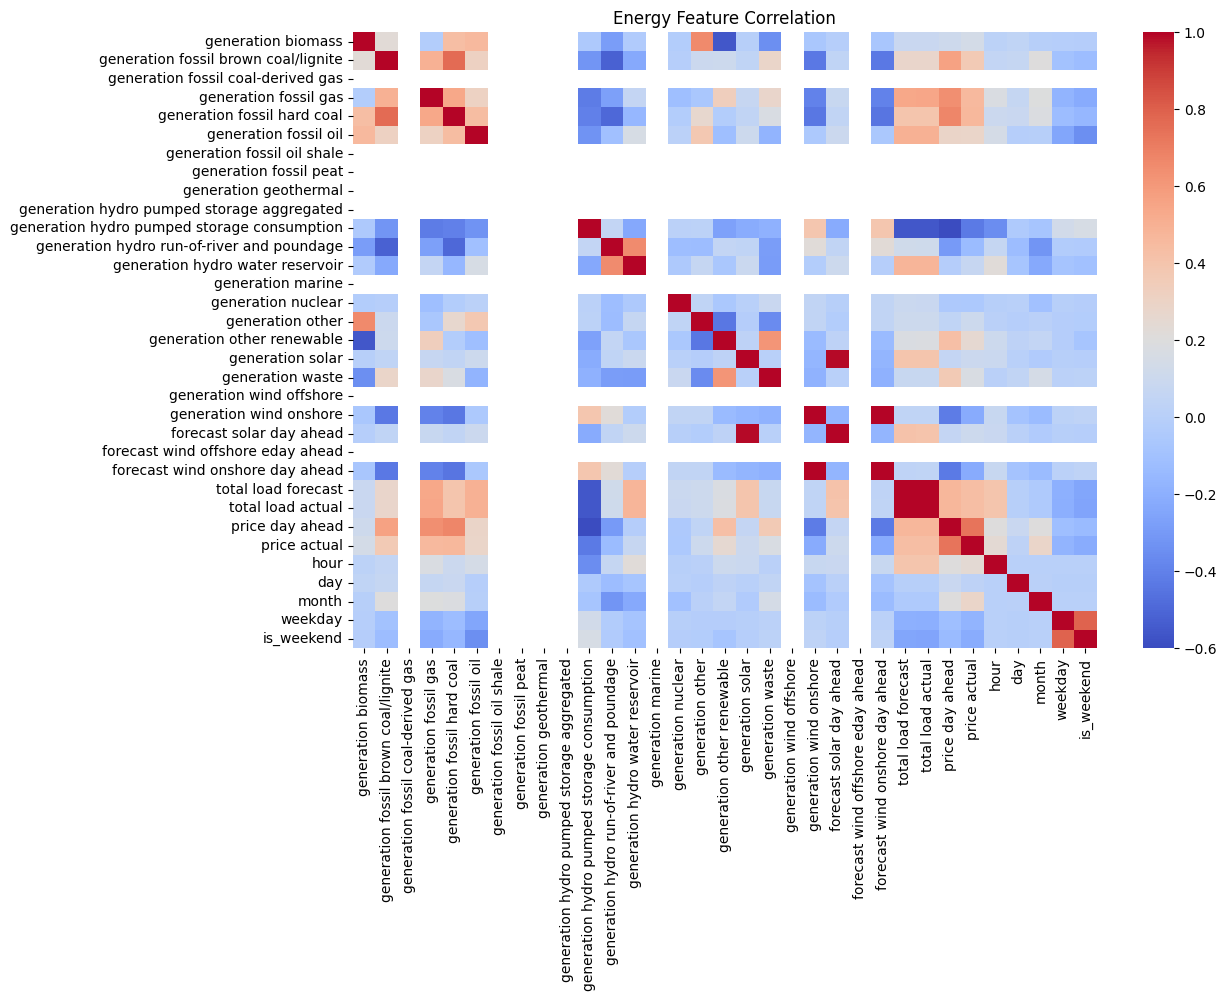

In [8]:
# Reload dataset (Safe Start)
energy_df = pd.read_csv(r"E:\OptiCore_AI\data\raw\energy_dataset.csv")

# Convert datetime
energy_df['time'] = pd.to_datetime(energy_df['time'], utc=True)

# Extract time features
energy_df['hour'] = energy_df['time'].dt.hour
energy_df['day'] = energy_df['time'].dt.day
energy_df['month'] = energy_df['time'].dt.month
energy_df['weekday'] = energy_df['time'].dt.weekday
energy_df['is_weekend'] = energy_df['weekday'].apply(lambda x: 1 if x >= 5 else 0)

# Select numeric columns only
numeric_df = energy_df.select_dtypes(include=np.number)

# Fill missing values
numeric_df = numeric_df.fillna(numeric_df.mean())

print("Numeric Feature Shape:", numeric_df.shape)

# Correlation Heatmap
if numeric_df.shape[0] > 10 and numeric_df.shape[1] > 2:
    plt.figure(figsize=(12,8))
    sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=False)
    plt.title("Energy Feature Correlation")
    plt.show()
else:
    print("Dataset not sufficient for correlation plot")